In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print("Shape of X:", X.shape)

Shape of X: (178, 13)


In [3]:
df = pd.DataFrame(X, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [7]:
print("Original Shape :", X.shape)

print("After PCA :", X_pca.shape)

Original Shape : (178, 13)
After PCA : (178, 2)


In [8]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


In [9]:
print(pca.explained_variance_ratio_)

[0.36198848 0.1920749 ]


In [10]:
print(sum(pca.explained_variance_ratio_))

0.5540633835693526


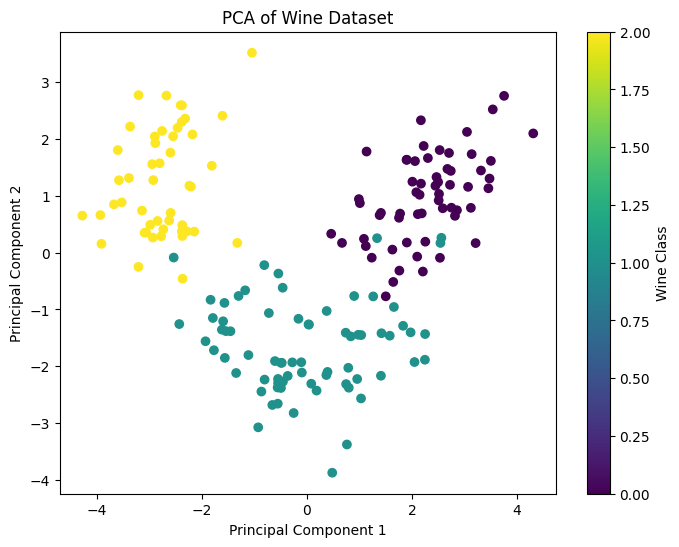

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset")

plt.colorbar(label="Wine Class")

plt.show()

In [12]:
print(pca.components_)

[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]]


In [13]:
#Accuracy without PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy without PCA:", accuracy_score(y_test, y_pred))

Accuracy without PCA: 1.0


In [14]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split PCA data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Train model
model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy with PCA:", accuracy_score(y_test, y_pred))

Accuracy with PCA: 1.0
